<a href="https://colab.research.google.com/github/Master-utsav/ML_3_Heart_Attack_Risk_Prediction/blob/main/ML_1_3_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [301]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [302]:
df = pd.read_csv("heart.csv")
df.head()
# df.info()
# df.shape
# df.columns

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Text(0, 0.5, 'Correlation with Heart Attack Risk')

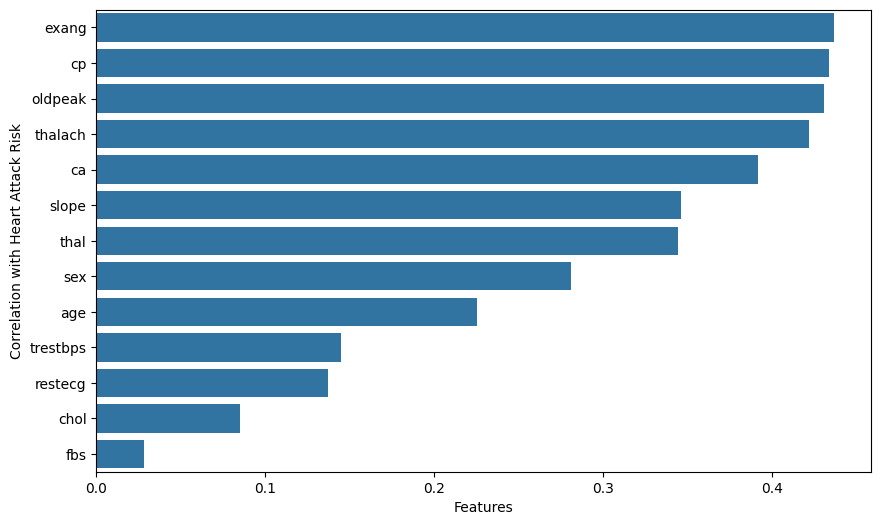

In [303]:
# checking correlation of heart attack risk with other features
corr = df.corr(numeric_only=True)['target'].drop('target')
corr = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr.values, y=corr.index)
plt.xlabel("Features")
plt.ylabel("Correlation with Heart Attack Risk")

In [304]:
df.rename(columns={
    'cp': 'Chest Pain Type',
    'ca': 'Number of Major Vessels',
    'oldpeak': 'ST Depression',
    'thal': 'Thalassemia Type',
    'thalach': 'Maximum Heart Rate',
    'age': 'Age',
    'chol': 'Cholesterol Level',
    'trestbps': 'Resting Blood Pressure',
    'exang': 'Exercise Induced Angina',
    'slope': 'ST Segment Slope',
    'sex': 'Gender',
    'restecg': 'Resting ECG Results',
    'fbs': 'Fasting Blood Sugar'
}, inplace=True)

In [305]:
X = df.drop(columns=['target'])
y = df['target']

In [306]:
X.columns

Index(['Age', 'Gender', 'Chest Pain Type', 'Resting Blood Pressure',
       'Cholesterol Level', 'Fasting Blood Sugar', 'Resting ECG Results',
       'Maximum Heart Rate', 'Exercise Induced Angina', 'ST Depression',
       'ST Segment Slope', 'Number of Major Vessels', 'Thalassemia Type'],
      dtype='object')

In [307]:
from sklearn.feature_selection import chi2

chi2_results = []

for col in X.columns:
    chi2_score, p_value = chi2(X[[col]], y)

    chi2_results.append({
        "feature": col,
        "chi2_score": chi2_score[0],
        "p_value": p_value[0],
        "decision": (
            "Reject null hypothesis (Accept Feature)"
            if p_value[0] < 0.05
            else "Accept null hypothesis (Reject Feature)"
        )
    })

chi2_df = pd.DataFrame(chi2_results)

chi2_df

,feature,chi2_score,p_value,decision
0,Age,23.286624,1.395673e-06,Reject null hypothesis (Accept Feature)
1,Gender,7.576835,5.912318e-03,Reject null hypothesis (Accept Feature)
2,Chest Pain Type,62.598098,2.534982e-15,Reject null hypothesis (Accept Feature)
3,Resting Blood Pressure,14.823925,1.180286e-04,Reject null hypothesis (Accept Feature)
4,Cholesterol Level,23.936394,9.957148e-07,Reject null hypothesis (Accept Feature)
5,Fasting Blood Sugar,0.202934,6.523632e-01,Accept null hypothesis (Reject Feature)
6,Resting ECG Results,2.978271,8.438939e-02,Accept null hypothesis (Reject Feature)
7,Maximum Heart Rate,188.320472,7.395102e-43,Reject null hypothesis (Accept Feature)
8,Exercise Induced Angina,38.914377,4.428074e-10,Reject null hypothesis (Accept Feature)
9,ST Depression,72.644253,1.552583e-17,Reject null hypothesis (Accept Feature)


In [308]:
filter_columns = chi2_df[chi2_df['decision'] == 'Reject null hypothesis (Accept Feature)']['feature'].tolist()
X_cleaned = X[filter_columns]
X_cleaned

,Age,Gender,Chest Pain Type,Resting Blood Pressure,Cholesterol Level,Maximum Heart Rate,Exercise Induced Angina,ST Depression,ST Segment Slope,Number of Major Vessels,Thalassemia Type
0,63,1,3,145,233,150,0,2.3,0,0,1
1,37,1,2,130,250,187,0,3.5,0,0,2
2,41,0,1,130,204,172,0,1.4,2,0,2
3,56,1,1,120,236,178,0,0.8,2,0,2
4,57,0,0,120,354,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,123,1,0.2,1,0,3
299,45,1,3,110,264,132,0,1.2,1,0,3
300,68,1,0,144,193,141,0,3.4,1,2,3
301,57,1,0,130,131,115,1,1.2,1,1,3


In [309]:
# X_cleaned['Thalassemia Type'].value_counts()
# X_cleaned['Number of Major Vessels'].value_counts()
# X_cleaned['ST Segment Slope'].value_counts()

In [310]:
X_cleaned = X_cleaned.drop(columns=['Number of Major Vessels', 'ST Segment Slope', 'ST Depression'])
X_clean_for_model = X_cleaned.copy()

In [333]:
X_clean_for_model.describe()

,Age,Gender,Chest Pain Type,Resting Blood Pressure,Cholesterol Level,Maximum Heart Rate,Exercise Induced Angina,Thalassemia Type
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,149.646865,0.326733,2.313531
std,9.082101,0.466011,1.032052,17.538143,51.830751,22.905161,0.469794,0.612277
min,29.000000,0.000000,0.000000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,133.500000,0.000000,2.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,153.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,166.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,202.000000,1.000000,3.000000


In [311]:
# first use the standarization one hot encoding
from sklearn.preprocessing import StandardScaler

filter_columns_for_encode = ['Age',
    'Resting Blood Pressure',
    'Cholesterol Level',
    'Maximum Heart Rate']
for col in filter_columns_for_encode:
    sc = StandardScaler()
    X_cleaned[col] = sc.fit_transform(X_cleaned[[col]])

In [312]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.2, random_state=42)
X_train.shape

(242, 8)

In [313]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import  GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

LogisticRegression()

In [314]:
y_pred = model_lr.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8360655737704918
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

Confusion Matrix:
 [[25  4]
 [ 6 26]]


In [315]:
model_dtree = DecisionTreeClassifier()
model_dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [316]:
y_pred = model_dtree.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7868852459016393
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.90      0.80        29
           1       0.88      0.69      0.77        32

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61

Confusion Matrix:
 [[26  3]
 [10 22]]


In [317]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [318]:
y_pred = model_knn.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9180327868852459
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.86      0.91        29
           1       0.89      0.97      0.93        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61

Confusion Matrix:
 [[25  4]
 [ 1 31]]


In [319]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

In [320]:
y_pred = model_nb.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8360655737704918
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.90      0.84        29
           1       0.89      0.78      0.83        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

Confusion Matrix:
 [[26  3]
 [ 7 25]]


In [321]:
model_svm = SVC()
model_svm.fit(X_train, y_train)

SVC()

In [322]:
y_pred = model_svm.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8688524590163934
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion Matrix:
 [[24  5]
 [ 3 29]]


In [323]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [324]:
y_pred = model_rf.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8360655737704918
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84        29
           1       0.92      0.75      0.83        32

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61

Confusion Matrix:
 [[27  2]
 [ 8 24]]


In [325]:
model_xg = XGBClassifier()
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [326]:
y_pred = model_xg.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8688524590163934
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Confusion Matrix:
 [[27  2]
 [ 6 26]]


In [336]:
# X_cleaned
# compraring the Thalassemia Type with the target at which value of thalaseemia the target is 1 sort in descending

In [337]:
# thalassemia_target_1 = df[df['target'] == 0]['Thalassemia Type'].value_counts().sort_index(ascending=False)
thalassemia_target_1 = df[df['target'] == 1]['Thalassemia Type'].value_counts().sort_index(ascending=False)
display(thalassemia_target_1)

,count
Thalassemia Type,
3,28
2,130
1,6
0,1


In [342]:
# chest_pain_type_target_1 = df[df['target'] == 0]['Chest Pain Type'].value_counts().sort_index(ascending=False)
chest_pain_type_target_1 = df[df['target'] == 1]['Chest Pain Type'].value_counts().sort_index(ascending=False)
display(chest_pain_type_target_1)

,count
Chest Pain Type,
3,16
2,69
1,41
0,39


In [328]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

scale_cols = [
    'Age',
    'Resting Blood Pressure',
    'Cholesterol Level',
    'Maximum Heart Rate'
]

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), scale_cols)
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_knn)
])

pipeline.fit(X_clean_for_model, y)


joblib.dump(pipeline, 'heart_attack_risk_check_model.joblib')

['heart_attack_risk_check_model.joblib']